In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from cablp.solvers._sim3 import LAPDSim

input_dict = {
    "gas_type": "He",
    "ne0": 1e9,
    "Tn_fit": 0.1,  # Neutral temperature for reaction rate fits
    "nn0": 5e12,
    "Source_nn0": 2e13,
    "Twin_nn0": 2e13,
    "Te0": 0.1,
    "Ti0": 0.1,
    "Bz0": 1500,  # Magnetic field in gauss
    "Lm": 1800,  # Length of machine
    "Rm": 50,  # Machine radius
    "Lp": 1800,  # Length of plasma
    "Rp": 18,  # Plasma radius
    "Rhf": 50,  # Gradient scale length of radial heat flux
    "Vd": 100,  # Discharge voltage
    "Twin_Vd": 100,
    "Id": 2500,  # Discharge current
    "Twin_Id": 2500,
    "anode_transparency": 1,  # Anode transparency
    "S_gp": 2000,  # Gas puff source rate
    "Twin_S_gp": 2000,
    "S_pump_L": 4000,  # Vacuum pump sink rate
    "S_pump_R": 4000,
    "tau_I_on": 0.001,  # Time constant for beam current rise
    "b_epara": 1.0,  # Scaling factor for e_para transport
    "b_ipara": 1.0,  # Scaling factor for i_para transport
    "b_eperp": 1.0,  # Scaling factor for e_perp transport
    "b_iperp": 1.0,  # Scaling factor for i_perp transport
    "b_ioniz": 1.0,  # Scaling factor for ionization
    "b_rec_rad": 1.0,  # Scaling factor for radiative recombination
    "b_rec_3b": 1.0,  # Scaling factor for three-body recombination
    "b_Qcx": 1.0,  # Scaling factor for charge exchange
    "b_source": 1.0,  # Scaling factor for source heating
    "b_Qie": 1.0,  # Scaling factor for ion-electron heating
    "b_Qei": 1.0,  # Scaling factor for electron-ion cooling
    "b_Qen": 1.0,  # Scaling factor for electron-neutral cooling
    "cycles": 1,
    "d_off": 20e-3,
    "dt_main": 1e-8,
    "end": 21e-3,
    "dt_after": 1e-7,
    "cells": 3,
}

input_flags = {
    "eperp": True,
    "iperp": True,
    "icool": True,
    "ncool": True,
    "cx": True,
    "mit_el": False,
    "C_imp": False,
    "O_imp": False,
    "icool_recomb": False,
    "Plasma": True,
    "TwinCathode": True,
    "Velocity": False,
}

voltage_array = [100, 100, 200, 100, 200]
current_array = [5000, 10000, 10000, 5000, 5000]
source_gp_array = [500, 500, 500, 250, 250]
twin_gp_array = [0, 0, 0, 250, 250]
source_nn0_array = [2e13, 2e13, 2e13, 1e13, 1e13]
twin_nn0_array = [0, 0, 0, 1e13, 1e13]
twin_flag_array = [False, False, False, True, True]

for i in range(5):
    input_dict["Vd"] = voltage_array[i]
    input_dict["Id"] = current_array[i]
    input_dict["Twin_Vd"] = voltage_array[i]
    input_dict["Twin_Id"] = current_array[i]
    input_dict["S_gp"] = source_gp_array[i]
    input_dict["Twin_S_gp"] = twin_gp_array[i]
    input_dict["Source_nn0"] = source_nn0_array[i]
    input_dict["Twin_nn0"] = source_nn0_array[i]
    input_flags["TwinCathode"] = twin_flag_array[i]
    fname = f"./data/sim_results_{i}.npz"
    print(fname)
    sim = LAPDSim(input_dict, input_flags)
    sim.start_simulation()
    np.savez(fname, **sim.get_results())


./data/sim_results_0.npz
Starting simulation...
Starting cycle 1/1...
Step 1/2010001:
ne= [9.99998435e+08 1.00000000e+09 9.99997420e+08], nn = [1.99999814e+13 5.00001935e+12 4.99999996e+12]
Te = [0.1        0.1        0.09999767], Ti = [0.09999995 0.1        0.09999995]
Step 5001/2010001:
ne= [9.50350631e+09 1.35784260e+09 9.58395194e+08], nn = [1.99066000e+13 5.09584375e+12 5.00010618e+12]
Te = [8.08998833 4.00313945 2.6243619 ], Ti = [0.10078231 0.1002689  0.10013598]
Step 10001/2010001:
ne= [2.48397339e+10 3.12063378e+09 1.01049038e+09], nn = [1.98133579e+13 5.18984374e+12 5.00082167e+12]
Te = [9.58544705 4.57162275 2.40118054], Ti = [0.10299663 0.10078185 0.10023807]
Step 15001/2010001:
ne= [4.69278733e+10 6.91325114e+09 1.30602586e+09], nn = [1.97201539e+13 5.28204488e+12 5.00213212e+12]
Te = [10.47839623  5.2272929   2.35526738], Ti = [0.10659822 0.10185305 0.10039175]
Step 20001/2010001:
ne= [8.00410788e+10 1.35860094e+10 2.05526737e+09], nn = [1.96262921e+13 5.37246422e+12 5.00

/var/folders/f_/5mm8drhn4xx8gvrr3dvx5x1m0000gn/T/ipykernel_26717/3070443729.py:106: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)


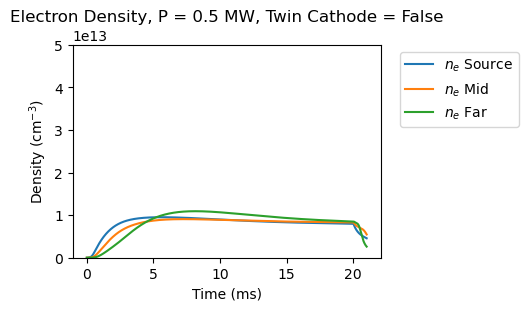

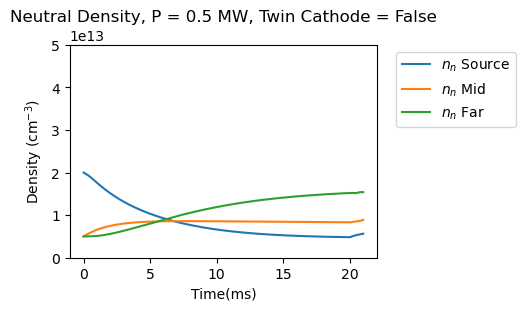

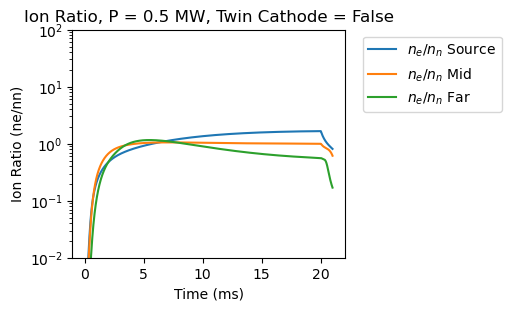

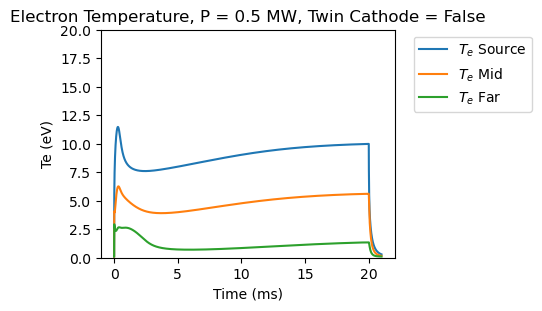

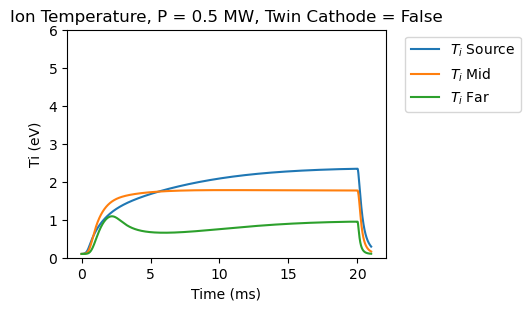

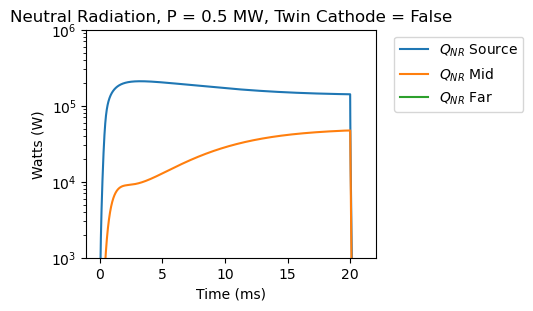

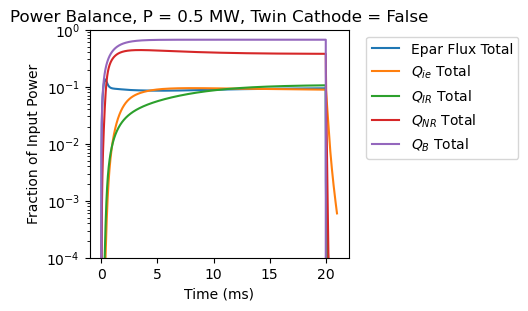

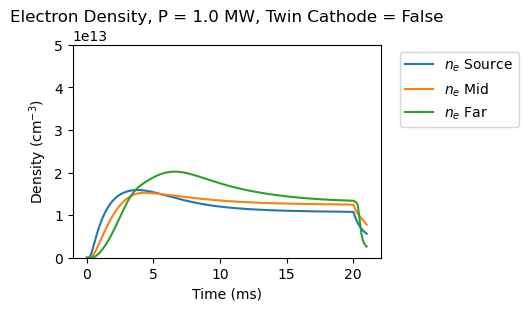

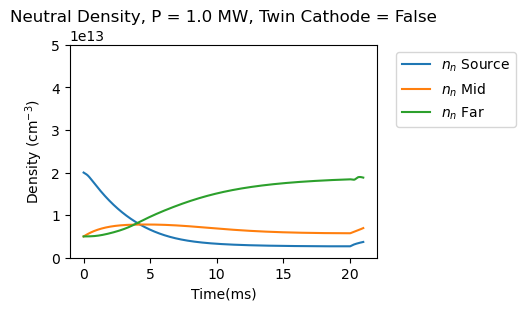

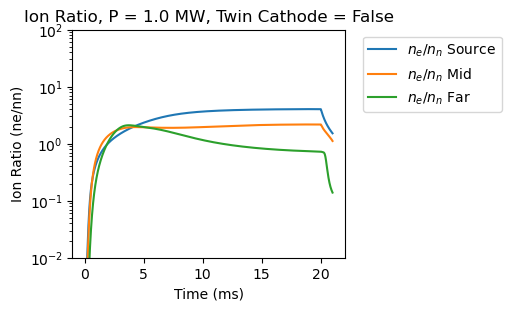

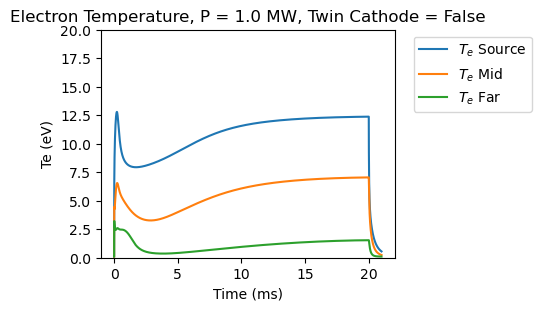

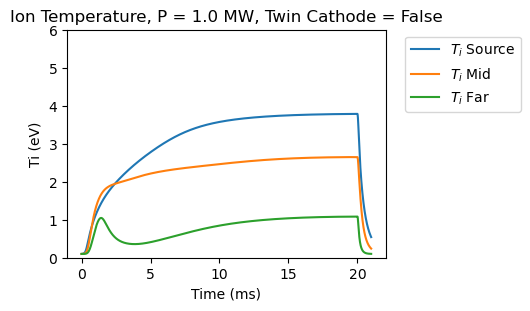

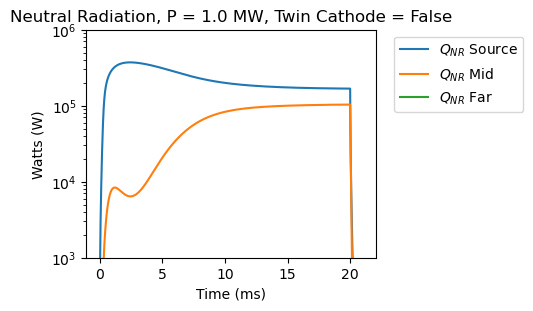

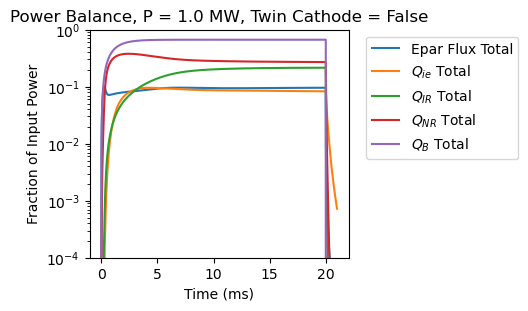

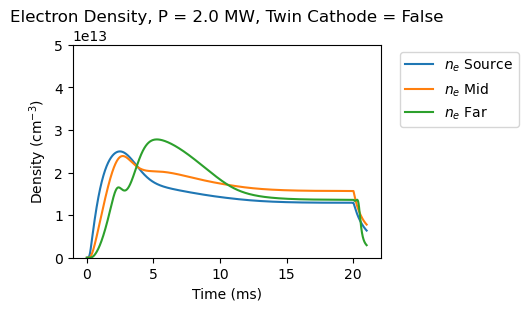

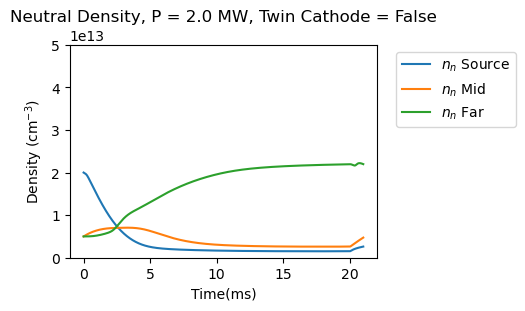

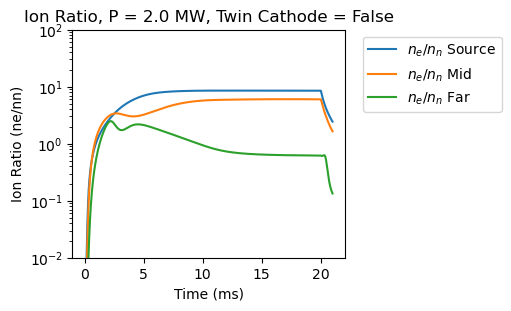

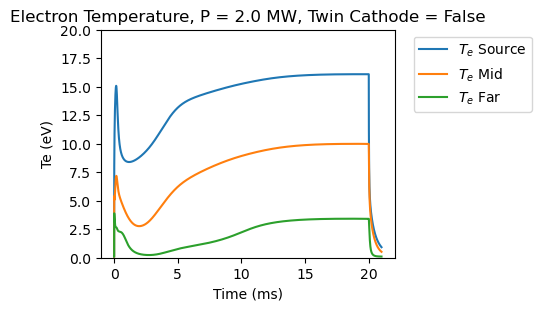

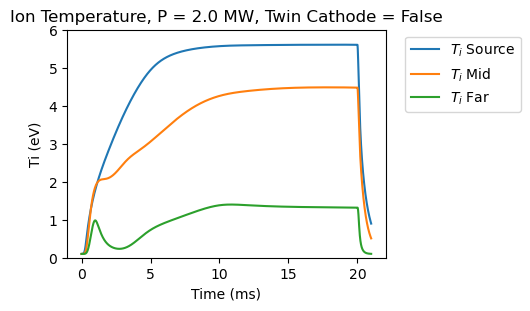

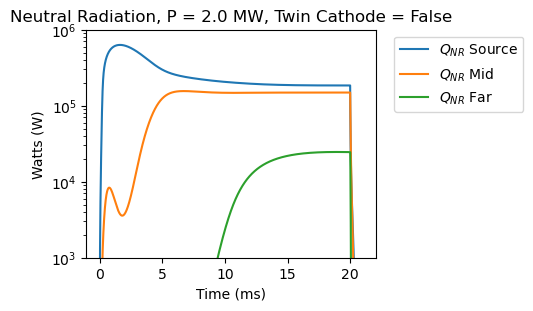

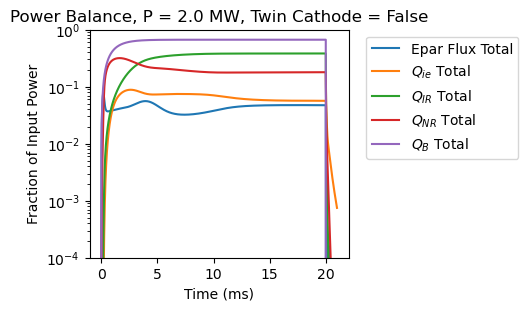

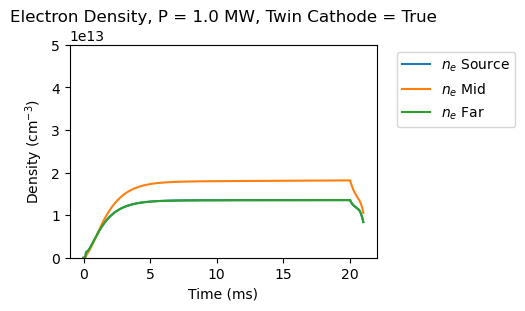

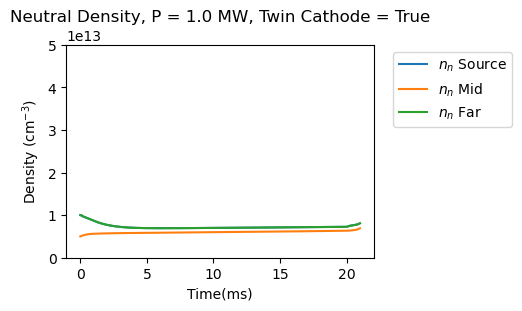

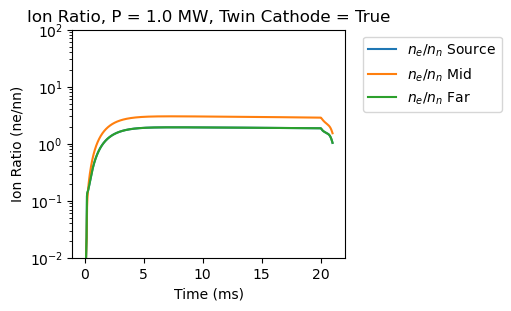

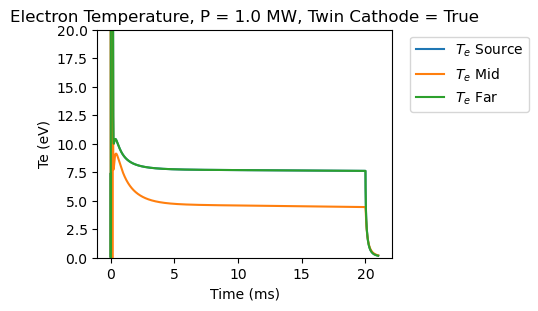

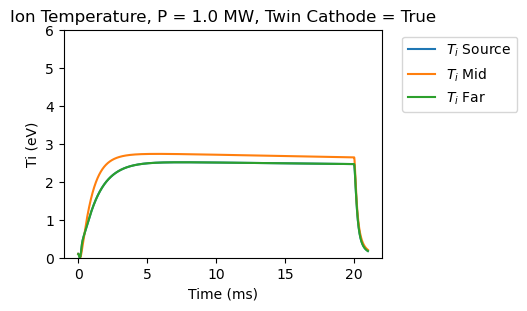

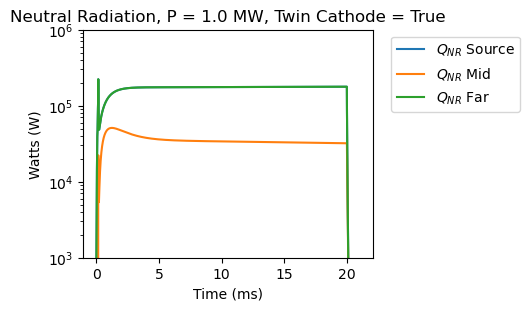

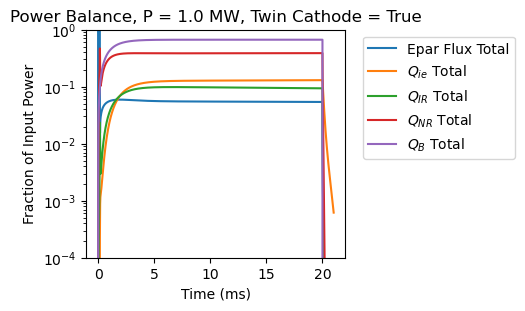

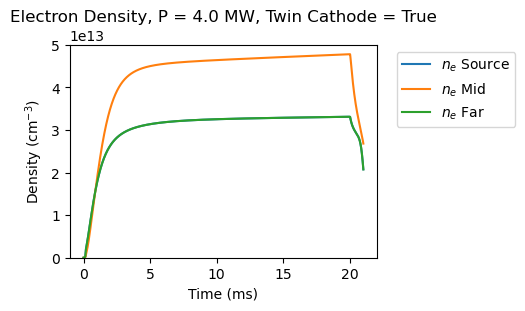

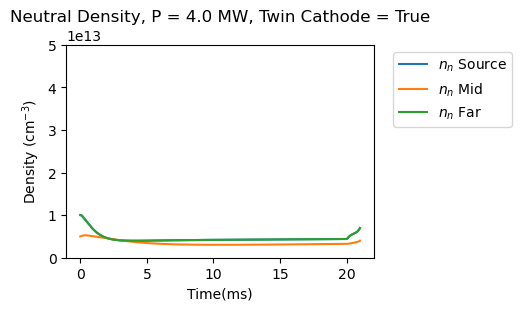

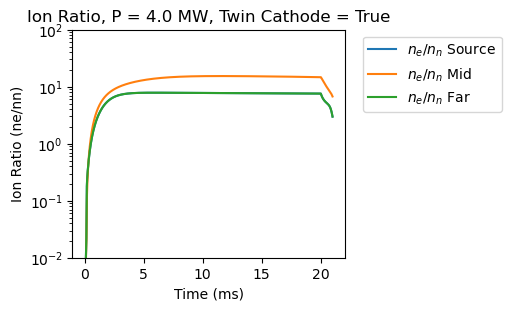

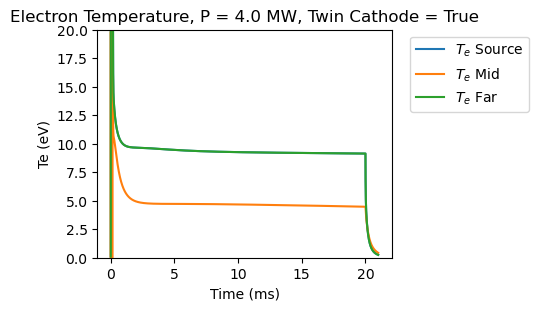

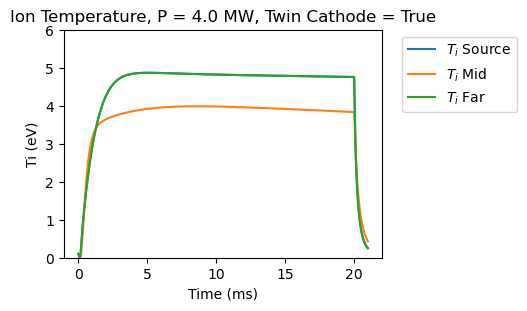

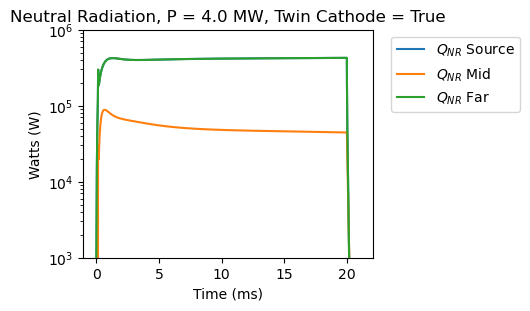

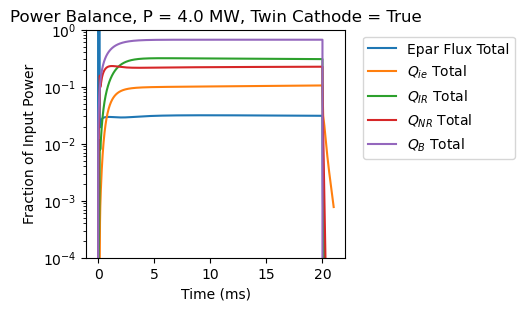

In [7]:
lapd_vol = np.pi * (18 ** 2) * 600  # cm^3
qe_si = 1.602e-19  # C
for i in range(5):
    input_dict["Vd"] = voltage_array[i]
    input_dict["Id"] = current_array[i]
    input_dict["Twin_Vd"] = voltage_array[i]
    input_dict["Twin_Id"] = current_array[i]
    input_dict["S_gp"] = source_gp_array[i]
    input_dict["Twin_S_gp"] = twin_gp_array[i]
    input_dict["Source_nn0"] = source_nn0_array[i]
    input_dict["Twin_nn0"] = source_nn0_array[i]
    input_flags["TwinCathode"] = twin_flag_array[i]
    results = np.load(f'./data/sim_results_{i}.npz')
    InputPower = input_dict["Vd"] * input_dict["Id"]  # Watts
    if input_flags["TwinCathode"]:
        InputPower += input_dict["Twin_Vd"] * input_dict["Twin_Id"]  # Watts
    IP_MW = InputPower / 1e6
    time = results["time"]
    ne = results["ne"]
    nn = results["nn"]
    Te = results["Te"]
    Ti = results["Ti"]
    e_par_flux = results["e_par_flux"]*qe_si*lapd_vol*ne
    e_par_flux_total = np.sum (e_par_flux, axis=1)
    Qie = results["Qie"]*qe_si*lapd_vol*ne
    Qie_total = np.sum(Qie, axis=1)
    Qei = results["Qei"]*qe_si*lapd_vol*ne
    Qei_total = np.sum(Qei, axis=1)
    Qen = results["Qen"]*qe_si*lapd_vol*ne
    Qen_total = np.sum(Qen, axis=1)
    Qeb = results["Qeb"]*qe_si*lapd_vol*ne
    Qeb_total = np.sum(Qeb, axis=1)
    Qbeam = results["Qbeam"]*qe_si*lapd_vol*ne
    Qbeam_total = np.sum(Qbeam, axis=1)
    Ion_frac = ne/nn
    i_par_flux = results["i_par_flux"]*qe_si*lapd_vol*ne
    i_perp_hl = results["i_perp_hl"]*qe_si*lapd_vol*ne
    Qcx = results["Qcx"]*qe_si*lapd_vol*ne

    fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
    ax.plot(time, ne[:, 0], label='$n_e$ Source')
    ax.plot(time, ne[:, 1], label='$n_e$ Mid')
    ax.plot(time, ne[:, 2], label='$n_e$ Far')
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    ax.set_ylabel('Density (cm$^{-3}$)')
    ax.set_ylim(0,5e13)
    ax.set_xlabel('Time (ms)')
    ax.set_title(f'Electron Density, P = {IP_MW} MW, Twin Cathode = {input_flags["TwinCathode"]}')
    fig.savefig(f'./plots/electron_density_{i}.png')

    fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
    ax.plot(time, nn[:, 0], label='$n_n$ Source')
    ax.plot(time, nn[:, 1], label='$n_n$ Mid')
    ax.plot(time, nn[:, 2], label='$n_n$ Far')
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    ax.set_ylabel('Density (cm$^{-3}$)')
    ax.set_ylim(0,5e13)
    ax.set_xlabel('Time(ms)')
    ax.set_title(f'Neutral Density, P = {IP_MW} MW, Twin Cathode = {input_flags["TwinCathode"]}')
    fig.savefig(f'./plots/neutral_density_{i}.png')

    fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
    ax.semilogy(time, Ion_frac[:, 0], label='$n_e$/$n_n$ Source')
    ax.semilogy(time, Ion_frac[:, 1], label='$n_e$/$n_n$ Mid')
    ax.semilogy(time, Ion_frac[:, 2], label='$n_e$/$n_n$ Far')
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    ax.set_ylim(1e-2,1e2)
    ax.set_ylabel('Ion Ratio (ne/nn)')
    ax.set_xlabel('Time (ms)')
    ax.set_title(f'Ion Ratio, P = {IP_MW} MW, Twin Cathode = {input_flags["TwinCathode"]}')
    fig.savefig(f'./plots/ion_ratio_{i}.png')

    fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
    ax.plot(time, Te[:, 0], label='$T_e$ Source')
    ax.plot(time, Te[:, 1], label='$T_e$ Mid')
    ax.plot(time, Te[:, 2], label='$T_e$ Far')
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    ax.set_ylabel('Te (eV)')
    ax.set_ylim(0, 20)
    ax.set_xlabel('Time (ms)')
    ax.set_title(f'Electron Temperature, P = {IP_MW} MW, Twin Cathode = {input_flags["TwinCathode"]}')
    fig.savefig(f'./plots/electron_temperature_{i}.png')

    fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
    ax.plot(time, Ti[:, 0], label='$T_i$ Source')
    ax.plot(time, Ti[:, 1], label='$T_i$ Mid')
    ax.plot(time, Ti[:, 2], label='$T_i$ Far')
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    ax.set_ylabel('Ti (eV)')
    ax.set_ylim(0,6)
    ax.set_xlabel('Time (ms)')
    ax.set_title(f'Ion Temperature, P = {IP_MW} MW, Twin Cathode = {input_flags["TwinCathode"]}')
    fig.savefig(f'./plots/ion_temperature_{i}.png')

    fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
    ax.semilogy(time, Qen[:, 0], label='$Q_{NR}$ Source')
    ax.semilogy(time, Qen[:, 1], label='$Q_{NR}$ Mid')
    ax.semilogy(time, Qen[:, 2], label='$Q_{NR}$ Far')
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    ax.set_ylabel('Watts (W)')
    ax.set_ylim(1e3, 1e6)
    ax.set_xlabel('Time (ms)')
    ax.set_title(f'Neutral Radiation, P = {IP_MW} MW, Twin Cathode = {input_flags["TwinCathode"]}')
    fig.savefig(f'./plots/neutral_radiation_{i}.png')

    fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
    ax.semilogy(time, np.abs(e_par_flux_total/InputPower), label='Epar Flux Total')
    ax.semilogy(time, Qie_total/InputPower, label='$Q_{ie}$ Total')
    ax.semilogy(time, Qei_total/InputPower, label='$Q_{IR}$ Total')
    ax.semilogy(time, Qen_total/InputPower, label='$Q_{NR}$ Total')
    ax.semilogy(time, Qeb_total/InputPower, label='$Q_B$ Total')
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    ax.set_ylabel('Fraction of Input Power')
    ax.set_ylim(1e-4, 1e0)
    ax.set_xlabel('Time (ms)')
    ax.set_title(f'Power Balance, P = {IP_MW} MW, Twin Cathode = {input_flags["TwinCathode"]}')
    fig.savefig(f'./plots/power_balance_{i}.png')


        # fig, ax = plt.subplots(1, 1, figsize=(5, 3), constrained_layout=True)
        # ax.semilogy(time, Qie[:, 1], label='Ion Heating Mid')
        # ax.semilogy(time, Qcx[:, 1], label='Charge Exchange Mid')
        # ax.semilogy(time, i_par_flux[:, 1], label='Ion Par Flux Mid')
        # ax.semilogy(time, i_perp_hl[:, 1], label='Ion Perp Flux Mid')
        # ax.legend()
        # ax.set_ylabel('Watts (W)')
        # ax.set_ylim(1e3, 1e6)

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from cablp.solvers._sim3 import LAPDSim

input_dict = {
    "gas_type": "He",
    "ne0": 1e9,
    "Tn_fit": 0.1,  # Neutral temperature for reaction rate fits
    "nn0": 5e12,
    "Source_nn0": 1e13,
    "Twin_nn0": 1e13,
    "Te0": 0.1,
    "Ti0": 0.1,
    "Bz0": 1500,  # Magnetic field in gauss
    "Lm": 1800,  # Length of machine
    "Rm": 50,  # Machine radius
    "Lp": 1800,  # Length of plasma
    "Rp": 18,  # Plasma radius
    "Rhf": 50,  # Gradient scale length of radial heat flux
    "Vd": 200,  # Discharge voltage
    "Twin_Vd": 200,
    "Id": 5000,  # Discharge current
    "Twin_Id": 5000,
    "anode_transparency": 1,  # Anode transparency
    "S_gp": 250,  # Gas puff source rate
    "Twin_S_gp": 250,
    "S_pump_L": 4000,  # Vacuum pump sink rate
    "S_pump_R": 4000,
    "tau_I_on": 0.001,  # Time constant for beam current rise
    "b_epara": 1.0,  # Scaling factor for e_para transport
    "b_ipara": 1.0,  # Scaling factor for i_para transport
    "b_eperp": 1.0,  # Scaling factor for e_perp transport
    "b_iperp": 1.0,  # Scaling factor for i_perp transport
    "b_ioniz": 1.0,  # Scaling factor for ionization
    "b_rec_rad": 1.0,  # Scaling factor for radiative recombination
    "b_rec_3b": 1.0,  # Scaling factor for three-body recombination
    "b_Qcx": 1.0,  # Scaling factor for charge exchange
    "b_source": 1.0,  # Scaling factor for source heating
    "b_Qie": 1.0,  # Scaling factor for ion-electron heating
    "b_Qei": 1.0,  # Scaling factor for electron-ion cooling
    "b_Qen": 1.0,  # Scaling factor for electron-neutral cooling
    "cycles": 1,
    "d_off": 20e-3,
    "dt_main": 1e-8,
    "end": 21e-3,
    "dt_after": 1e-7,
    "cells": 3,
}

input_flags = {
    "eperp": True,
    "iperp": True,
    "icool": True,
    "ncool": True,
    "cx": True,
    "mit_el": False,
    "C_imp": False,
    "O_imp": False,
    "icool_recomb": False,
    "Plasma": True,
    "TwinCathode": True,
    "Velocity": False,
}
i=5
voltage_array = [100, 100, 200, 100,0, 200]
current_array = [5000, 10000, 10000, 5000,0, 5000]
source_gp_array = [500, 500, 500, 250,0, 250]
twin_gp_array = [0, 0, 0, 250,0, 250]
source_nn0_array = [2e13, 2e13, 2e13, 1e13,0, 1e13]
twin_nn0_array = [0, 0, 0, 1e13,0, 1e13]
twin_flag_array = [False, False, False, True,True, True]
input_dict["Vd"] = voltage_array[i]
input_dict["Id"] = current_array[i]
input_dict["Twin_Vd"] = voltage_array[i]
input_dict["Twin_Id"] = current_array[i]
input_dict["S_gp"] = source_gp_array[i]
input_dict["Twin_S_gp"] = twin_gp_array[i]
input_dict["Source_nn0"] = source_nn0_array[i]
input_dict["Twin_nn0"] = source_nn0_array[i]
input_flags["TwinCathode"] = twin_flag_array[i]
fname = f"./data/sim_results_{i}.npz"
print(fname)
sim = LAPDSim(input_dict, input_flags)
sim.start_simulation()
np.savez(fname, **sim.get_results())
